## Module 4: 

## Team Members:
Asma Sanaullah & Makayla Adams
## Project Title:
Comparing Growth Signaling in Glioblastoma Multiforme (GBM) and Lower Grade Glioma (LGG)


## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

This project seeks to compare the genes in involved in the hallmark sustained proliferative growth signaling between Glioblastoma Multiforme (GBM) and Lower Grade Glioma (LGG), two brain tumors. GBM is a higher grade than LGG and since a higher grade implies a more aggressive form of cancer, we are interested to see if that leads to a difference in growth signlaing between the two cancer types. We aim to do this by analyzing the gene expression of signaling genes to determine how sustained proliferative signaling drives the aggressive growth and progression of these two brain cancers. 

## Disease Background:
*Pick a hallmark to focus on, and figure out what genes you are interested in researching based on that decision. Then fill out the information below.*

* Cancer hallmark focus:
* Overview of hallmark:
* Genes associated with hallmark to be studied (you can point to a CSV with the list of genes you will study, or point to a citation with a gene signature of interest)

*Will you be focusing on a single cancer type or looking across cancer types? Depending on your decision, update this section to include relevant information about the disease at the appropriate level of detail. Regardless, each bullet point should be filled in. If you are looking at multiple cancer types, you should investigate differences between the types (e.g. what is the most prevalent cancer type? What type has the highest mortality rate?) and similarities (e.g. what sorts of treatments exist across the board for cancer patients? what is common to all cancers in terms of biological mechanisms?)*

* Prevalence & incidence
* Risk factors (genetic, lifestyle) & Societal determinants
* Standard of care treatments (& reimbursement) 
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)


## Data-Set: 

*Once you decide on the subset of data you want to use (i.e. only 1 cancer type or many; any clinical features needed?; which genes will you look at?) describe the dataset. There are a ton of clinical features, so you don't need to describe them all, only the ones pertinent to your question.*

*(Describe the data set(s) you will analyze. Cite the source(s) of the data. Describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.) Include any visualizations from your exploratory data analysis here*

The subset of data we will analyze in this project focuses on two types of brain tumors, Glioblastoma Multiforme and Brain Lower Grade Glioma, each with 80 samples. The goal here is to compare high and low grade gliomas by looking at the sustaining growth signaling hallmark to see how these signaling pathways and uncontrolled growth differ and how gene expression can relate. We subsetted the data to only conclude these two cancers and we selected relevant genes present in the data, including MKI67, AKT1, EGFR, CDK1, CDK2, AURKA and AURKB. These genes are associated with cell proliferation and growth signaling pathways. We confirmed that these genes were present in the data and based on our exploratory data analysis. We won’t be looking at clinical features right now as we simply want to focus on the difference in how genes are expressed. 

This dataset comes from the paper, Alternative preprocessing of RNA-Sequencing data in The Cancer Genome Atlas leads to improved analysis results. Here researchers used The Cancer Genome Atlas (TCGA) RNA-sequencing data and reprocessed it to make gene expression measurements more consistent and usable for analysis. RNA sequencing measures gene expression throughmRNA transcripts which shows how much a gene is active. Researchers made it easier to compare “gene-level expression values across samples” which is useful for our project goal. RNA seq can be interpreted by the data normalization method TPM (transcripts per million) which is used to account for sequencing depth and length. The gene expression here was calculated as log2 transformed to reduce chances of skewed data. It also allows for a more direct comparison of gene expression levels fairly. 



#### Exploratory Analysis & Subsetting the Data for Cancer Type & Genes


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# %%
# Load the data from both the gene expression and metadata files
data = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)

metadata_df = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)

# print the first few rows of this gene expression data
print(data.head())

# %%
# Here the data is explored by looking at its shape, info and summary stats.
print(data.shape)
print(data.info())
print(data.describe())

# %%
# Explore the metadata to see the sample characteristics
print(metadata_df.info())
print(metadata_df.describe())

# %%
# Subset the data for specific cancer types (GBM and LGG)
cancer_types = ['GBM', 'LGG']

# cancer_samples has the sample IDs for the selected GBM and LGG samples
cancer_samples = metadata_df[metadata_df['cancer_type'].isin(cancer_types)].index
print("Selected samples:", cancer_samples)

# Subset expression data
subset_data = data[cancer_samples]

# %%
# Subset by index with genes of interest
desired_gene_list = [
    'MKI67','CDK1','CDK2','AURKA','AURKB',
    'EGFR','AKT1'
]

# Check which genes are present
gene_list = [gene for gene in desired_gene_list if gene in subset_data.index]

for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")

print("Genes found in dataset:", gene_list)

# Subset to selected genes
subset_gene_data = subset_data.loc[gene_list]
print(subset_gene_data.head())

# %%
# Basic statistics on the subsetted data
####################################################
print(subset_gene_data.describe())

# Variance across samples for each gene
print("Variance per gene:")
print(subset_gene_data.var(axis=1))

# Mean expression across samples
print("Mean expression per gene:")
print(subset_gene_data.mean(axis=1))

# Median expression
print("Median expression per gene:")
print(subset_gene_data.median(axis=1))

# %%
# Compare GBM vs LGG expression
####################################################
GBM_ids = metadata_df[metadata_df['cancer_type'] == 'GBM'].index
LGG_ids = metadata_df[metadata_df['cancer_type'] == 'LGG'].index

print("\nMean expression in GBM vs LGG:")

for gene in gene_list:
    gbm_mean = data.loc[gene, GBM_ids].mean()
    lgg_mean = data.loc[gene, LGG_ids].mean()
    print(f"{gene}: GBM={gbm_mean:.2f}, LGG={lgg_mean:.2f}")

# %%
# Explore categorical variables in metadata
####################################################
print(metadata_df.groupby('cancer_type')["gender"].value_counts())

# Explore average age at diagnosis
metadata_df['age_at_diagnosis'] = pd.to_numeric(
    metadata_df['age_at_diagnosis'], errors='coerce')

print(metadata_df.groupby('cancer_type')["age_at_diagnosis"].mean())

# %%
# Merging datasets
####################################################
# Merge gene expression with metadata for selected samples
subset_metadata = metadata_df.loc[cancer_samples]

merged_df = subset_gene_data.T.merge(
    subset_metadata,
    left_index=True,
    right_index=True
)

print(merged_df.head())

# %%
# Plotting
####################################################
# Boxplot: MKI67 expression by cancer type
sns.boxplot(data=merged_df, x="cancer_type", y='MKI67')
plt.title("MKI67 Expression: GBM vs LGG")
plt.show()

# Boxplot: multiple genes
merged_df[gene_list].plot.box()
plt.title("Distribution of Proliferation and Signaling Genes")
plt.xticks(rotation=45)
plt.show()

# Scatterplot: relationship between two genes
sns.scatterplot(data=merged_df, x="MKI67", y="CDK1", hue="cancer_type")
plt.title("MKI67 vs CDK1 Expression")
plt.show()


#### Results of Exploratory Analysis & Summary Statistics

Mean Expression in GBM vs LGG
MKI67: GBM=3.25, LGG=2.28
CDK1: GBM=4.46, LGG=2.69
CDK2: GBM=5.44, LGG=4.02
AURKA: GBM=3.82, LGG=2.23
AURKB: GBM=4.81, LGG=2.68
EGFR: GBM=6.49, LGG=5.73
AKT1: GBM=7.23, LGG=7.22


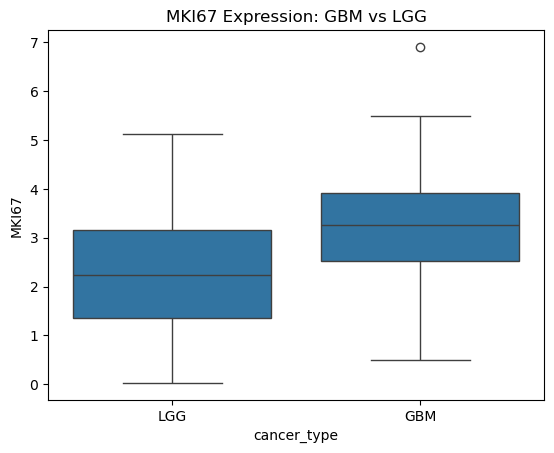


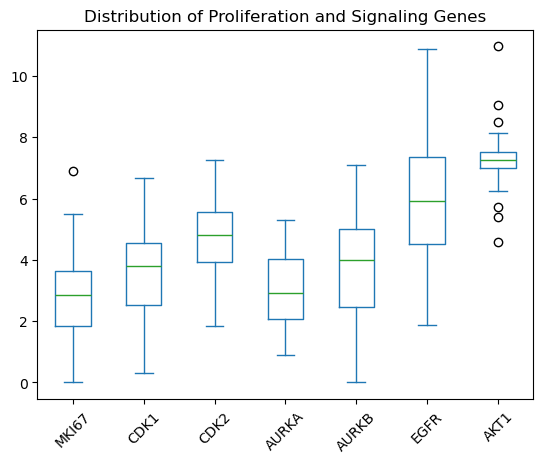

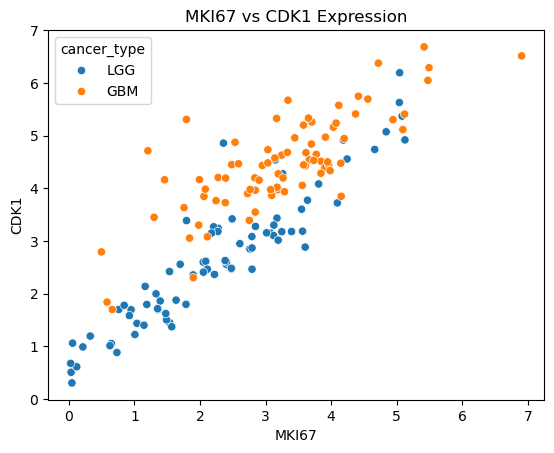

## Data Analysis: 

### Methods
The machine learning technique I am using is: *fill in and describe*

*What is this method optimizing? How does the model decide it is "good enough"?*

**

### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*